# Script for plotting porosity dynamics for one cycle at 1C

In [136]:
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
import pandas as pd
import matplotlib
import matplotlib.ticker as tck

# Global plotting defaults used by all figures in this notebook.
FONT = {"size": 12}
matplotlib.rc("font", **FONT)
plt.rcParams["axes.labelsize"] = 14

# Directory containing the exported EMSI CSV files for this study.
folder = Path("../raw_data")

## Import the full dataset containing the porosity dynamics

In [139]:
header = open(folder / "porosity_dynamics.csv")
header = header.readlines()[6].split(',')[1:]
for i in range(len(header)):
    header[i] = header[i][1:]
header[-1] = header[-1][:-2]

df = pd.read_csv(folder / "porosity_dynamics.csv", skiprows=8, sep=',', names=header)

# Convert units and multiply by 4 to account for double-sided coating and symmetry plane
df['Reservoir volume'] *= 4e6
df['Stack volume'] *= 4e6
df.index /= 60

# Print header names
header

['Cell potential',
 'Porosity anode',
 'Porosity separator',
 'Porosity cathode',
 'Total strain anode',
 'Total strain separator',
 'Total strain cathode',
 'Inelastic strain anode',
 'Inelastic strain separator',
 'Inelastic strain cathode',
 'Elastic strain anode',
 'Elastic strain separator',
 'Elastic strain cathode',
 'Average SOC anode',
 'Average SOC cathode',
 'SOL_graphite',
 'SOL_silicon',
 'Reservoir volume',
 'Stack volume',
 'Stack pressure']

## Plot the porosity evolution and electrolyte volume in the stack and reservoir
##### During a 0.5C cycle, this porosity in all components decreases during charging, pushing electrolyte out of the stack and into the reservoir. During dishcarge, the process reverses

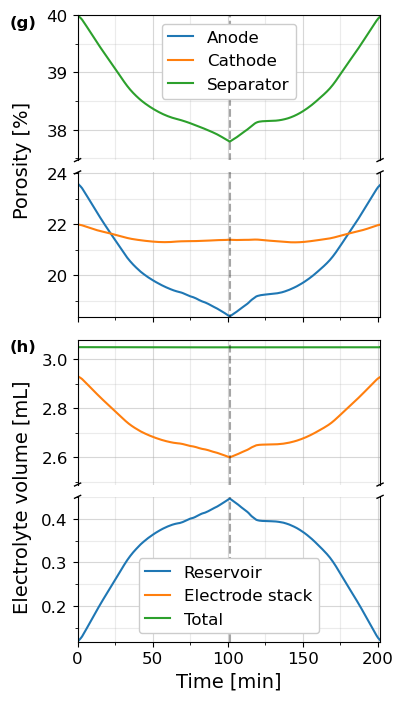

In [141]:
fig, axs = plt.subplots(
    4, 1, sharex=True, figsize=(4.2, 7.2)
)

ax_top, ax_bot, ax2_top, ax2_bot = axs

# y-range to hide (porosity)
ybreak_low, ybreak_high = 24.03, 37.47

# y-range to hide (volume)
ybreak_low2, ybreak_high2 = 0.451, 2.49

# ----------------
# Porosity (broken y)
# ----------------
for ax in (ax_top, ax_bot):
    ax.plot(df.index, df["Porosity anode"]*100, label="Anode")
    ax.plot(df.index, df["Porosity cathode"]*100, label="Cathode")
    ax.plot(df.index, df["Porosity separator"]*100, label="Separator")
    ax.grid(alpha=0.5)
    ax.set_xlim(0, df.index.max())
    ax.vlines(6074.6/60, *ax.get_ylim(), linestyle="--", color="k", alpha=0.35)

ymin = min(
    (df["Porosity anode"]*100).min(),
    (df["Porosity cathode"]*100).min(),
    (df["Porosity separator"]*100).min(),
) * 0.99
ymax = max(
    (df["Porosity anode"]*100).max(),
    (df["Porosity cathode"]*100).max(),
    (df["Porosity separator"]*100).max(),
)

ax_bot.set_ylim(ymin+0.15, ybreak_low)
ax_top.set_ylim(ybreak_high, ymax)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labelbottom=False, labeltop=False)
ax_bot.tick_params(labeltop=False)

d = 0.01
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False, linewidth=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

#fig.text(0.04 + 0.005, 0.75-0.05, "Porosity [%]", va="center", rotation="vertical")
ax_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
ax_top.set_ylabel("Porosity [%]")

ax_top.legend(loc="upper center", framealpha=1, fontsize="medium", handlelength=1.5)

# ----------------
# Volume (broken y)
# ----------------
for ax in (ax2_top, ax2_bot):
    ax.plot(df.index, df["Reservoir volume"], label="Reservoir", linestyle="-")
    ax.plot(df.index, df["Stack volume"], label="Electrode stack", linestyle="-")
    ax.plot(df.index, df["Stack volume"] + df["Reservoir volume"], label="Total", linestyle="-")
    ax.grid(alpha=0.5)
    ax.set_xlim(0, df.index.max())

ymin2 = min(
    df["Reservoir volume"].min(),
    df["Stack volume"].min(),
    (df["Stack volume"] + df["Reservoir volume"]).min(),
)
ymax2 = max(
    df["Reservoir volume"].max(),
    df["Stack volume"].max(),
    (df["Stack volume"] + df["Reservoir volume"]).max() * 1.01,
)

ax2_bot.set_ylim(ymin2, ybreak_low2)
ax2_top.set_ylim(ybreak_high2, ymax2)

for ax in (ax2_top, ax2_bot):
    ax.vlines(6074.6/60, *ax.get_ylim(), linestyle="--", color="k", alpha=0.35)

ax2_top.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

ax2_top.spines["bottom"].set_visible(False)
ax2_bot.spines["top"].set_visible(False)

d = 0.01
kwargs = dict(transform=ax2_top.transAxes, color="k", clip_on=False, linewidth=1)
ax2_top.plot((-d, +d), (-d, +d), **kwargs)
ax2_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax2_bot.transAxes)
ax2_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax2_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax2_bot.set_ylabel(r"Electrolyte volume [mL]")
ax2_bot.yaxis.set_label_coords(-0.15,1)
ax_top.yaxis.set_label_coords(-0.15,0)
fig.align_ylabels()

ax2_bot.set_xlabel("Time [min]")
ax2_bot.legend(loc="lower center", fontsize="medium", framealpha=1, handlelength=1.5)

plt.tight_layout()
fig.canvas.draw()

def y0y1(ax):
    p = ax.get_position()
    return p.y0, p.y1, p.height, p.x0, p.width*1.2

# current positions
p1 = ax_top.get_position()
p2 = ax_bot.get_position()
p3 = ax2_top.get_position()
p4 = ax2_bot.get_position()

# current gaps (in figure coordinates)
g12 = p1.y0 - p2.y1
g23 = p2.y0 - p3.y1
g34 = p3.y0 - p4.y1

# choose how tight to make gaps 1–2 and 3–4 (smaller => tighter)
factor12 = 0.5   # keep 50% of the current 1–2 gap
factor34 = 0.5   # keep 50% of the current 3–4 gap

g12_new = g12 * factor12
g34_new = g34 * factor34
g23_new = g23*0.91

# total freed space from shrinking (1–2 and 3–4)
delta = (g12 + g34) - (g12_new + g34_new)

# scale ALL axis heights up proportionally to absorb freed space
h1, h2, h3, h4 = p1.height, p2.height, p3.height, p4.height
sum_h = h1 + h2 + h3 + h4
scale = (sum_h + delta) / sum_h

h1n, h2n, h3n, h4n = h1 * scale, h2 * scale, h3 * scale, h4 * scale

# Re-stack from bottom up, preserving bottom margin (p4.y0) and top margin automatically
y = p4.y0
ax2_bot.set_position([p4.x0, y, p4.width, h4n])

y = y + h4n + g34_new
ax2_top.set_position([p3.x0, y, p3.width, h3n])

y = y + h3n + g23_new
ax_bot.set_position([p2.x0, y, p2.width, h2n])

y = y + h2n + g12_new
ax_top.set_position([p1.x0, y, p1.width, h1n])

ax2_bot.set_yticks(np.arange(0.2,0.5,0.1))
ax2_top.set_xticks(np.arange(0,200.1,50))
ax2_bot.set_xticks(np.arange(0,200.1,50))

for ax in axs:
    ax.grid(alpha=0.25, which="minor")
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_xticks(np.arange(0,200.1,50))

fig.align_ylabels()
ax_top.text(-45, ax_top.get_ylim()[1], "(g)", weight="bold", verticalalignment="top")
ax2_top.text(-45, ax2_top.get_ylim()[1], "(h)", weight="bold", verticalalignment="top")


plt.savefig("../plots/porosity_volume.png", format="png", transparent=True, dpi=500)


In [143]:
print("Amount of expelled electrolyte: " + str(np.round(df["Reservoir volume"].max() - df["Reservoir volume"].min(), 2)) + " mL")

Amount of expelled electrolyte: 0.33 mL


## Plot cell potential, state of charge, and stack pressure
##### During a 0.5C cycle, the state of charge varies in the different active materials, and the stack pressure increases due to active material expansion

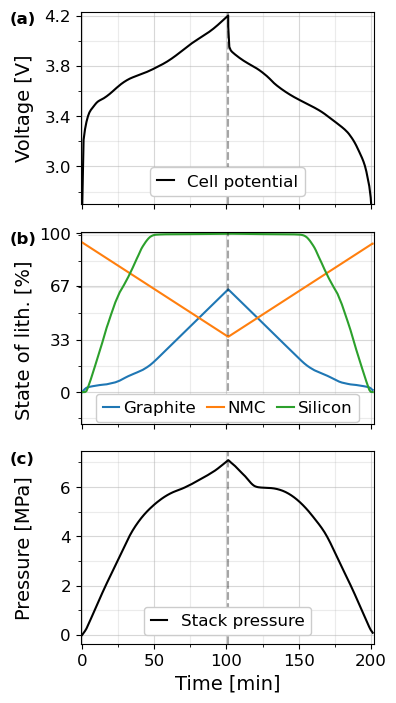

In [145]:
fig, (ax2, ax1, axP) = plt.subplots(
    3, 1,
    sharex=True,
    figsize=(4.2, 7.2),
)

# --- Stack pressure (top) ---
t_switch = 6074.6/60
axP.plot(df.index, df["Stack pressure"]/1e6, label=r"Stack pressure", color='k')
axP.grid(alpha=0.5)
ylims=axP.get_ylim()
axP.set_yticks(np.arange(0,8.01,2))
axP.set_ylim(*ylims)
axP.set_xlim(0, df.index.max())
axP.vlines(t_switch, *axP.get_ylim(), linestyle='--', color='k', alpha=0.35)
axP.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
axP.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))

# legend inside
axP.legend(loc="lower center", frameon=True, framealpha=1, fontsize="medium", handlelength=1.0)

#axP.set_xticklabels([])
axP.set_ylabel("Pressure [MPa]")

# --- Top: State of lithiation ---
ax1.plot(df.index, df["SOL_graphite"]*100, label="Graphite", color='tab:blue')
ax1.plot(df.index, df["Average SOC cathode"]*100, label="NMC", color='tab:orange')
ax1.plot(df.index, df["SOL_silicon"]*100, label="Silicon", color='tab:green')

ax1.axvline(t_switch, linestyle="--", color="k", alpha=0.35)
ax1.grid(alpha=0.5)
ax1.set_xlim(-1, df.index.max()+1)
ax1.set_ylabel("State of lith. [%]    ")
ax1.legend(loc="lower center", ncol=3, columnspacing=0.7, frameon=True, framealpha=1, fontsize="medium", handlelength=1, handletextpad=0.2, borderaxespad=0.1)
ax1.set_ylim(-20, 101)

# --- Bottom: Cell potential ---
ax2.plot(df.index, df["Cell potential"], color="k", label="Cell potential")
ax2.legend(loc="lower center", frameon=True, framealpha=1, fontsize="medium", handlelength=1.0)
ax2.axvline(t_switch, linestyle="--", color="k", alpha=0.35)
ax2.grid(alpha=0.5)
ax2.set_xlim(-1, df.index.max()+1)
ax2.set_ylabel("Voltage [V]")
axP.set_xlabel("Time [min]")
ax1.set_xticks(np.arange(0,200.1,50))
ax2.set_xticks(np.arange(0,200.1,50))
ax1.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax1.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax2.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax2.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
ax1.set_yticks(np.round(np.arange(0,100.1,33.3), 0))
ax2.set_yticks(np.arange(2.6,4.26, 0.4))
ax2.set_ylim(2.7, 4.23)
ax1.text(-50, ax1.get_ylim()[1], "(b)", weight="bold", verticalalignment="top")
ax2.text(-50, ax2.get_ylim()[1], "(a)", weight="bold", verticalalignment="top")
axP.text(-50, axP.get_ylim()[1], "(c)", weight="bold", verticalalignment="top")

axP.grid(alpha=0.25, which='minor')
ax1.grid(alpha=0.25, which='minor')
ax2.grid(alpha=0.25, which='minor')

fig.align_ylabels()


plt.tight_layout()
plt.savefig("../plots/cell_pot_sol.png", format="png", transparent=True, dpi=500)

## Plot the strain of individual electrodes and separator
##### The elastic and inelastic strain develop during a cycle at 0.5C, which is the cause of the porosity evolution seen above

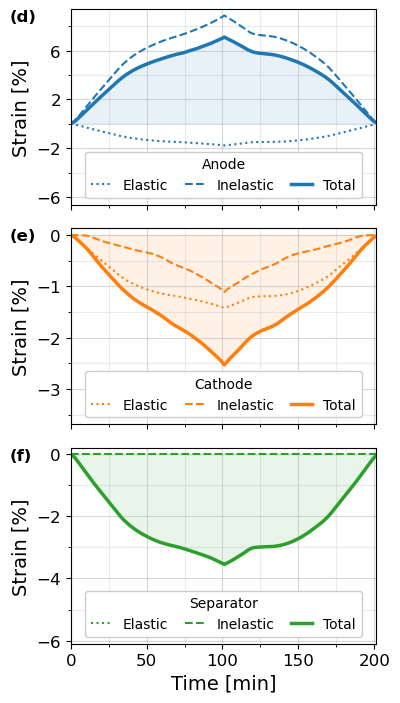

In [147]:
t_switch = 6074.6/60
colors = {'anode': 'tab:blue', 'cathode': 'tab:orange', 'separator': 'tab:green'}
components = ['anode', 'cathode', 'separator']
Components = ['Anode', 'Cathode', 'Separator']

fig, axes = plt.subplots(
    3, 1, figsize=(4.2, 7.2), sharex=True
)

# --- Strain subplots (3 panels) ---
for i, comp in enumerate(components):
    ax = axes[i]

    elastic   = df[f"Elastic strain {comp}"]   * 100
    inelastic = df[f"Inelastic strain {comp}"] * 100
    total     = df[f"Total strain {comp}"]     * 100

    ax.plot(df.index, elastic,   label="Elastic",   linestyle=':',  color=colors[comp], lw=1.5)
    ax.plot(df.index, inelastic, label="Inelastic", linestyle='--', color=colors[comp], lw=1.5)
    ax.plot(df.index, total,     label="Total",     linestyle='-',  color=colors[comp], lw=2.5)
    ax.fill_between(df.index, 0, total, color=colors[comp], alpha=0.1)
    ylims=ax.get_ylim()
    if i == 1:
        ax.set_yticks(np.arange(-4,0.01,1))
    if i == 0:
        ax.set_yticks(np.arange(-6,7.01,4))

    ax.grid(alpha=0.5, which='major')
    ax.grid(alpha=0.25, which='minor')
    ax.set_ylim(ylims[0]-0.37*(ylims[1]-ylims[0]), ylims[1])
    if i == 2:
        ax.set_yticks(np.arange(-6,0.03,2))
        ax.set_ylim(-6.1, 0.2)
    ax.set_xlim(0, df.index.max())
    ax.set_ylabel("Strain [%]" if i != 0 else "Strain [%]")
    ax.xaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.yaxis.set_minor_locator(tck.AutoMinorLocator(n=2))
    ax.set_xticks(np.arange(0,200.1,50))
    
    # legend inside + keep the "title" per subplot
    ax.legend(loc="lower center", frameon=True, title=Components[i], framealpha=1, fontsize="small", handlelength=1.5, title_fontsize="small", ncols=3, columnspacing=1.2)

axes[-1].set_xlabel("Time [min]")
fig.align_labels()
axes[0].text(-40, axes[0].get_ylim()[1], "(d)", weight="bold", verticalalignment="top")
axes[1].text(-40, axes[1].get_ylim()[1], "(e)", weight="bold", verticalalignment="top")
axes[2].text(-40, axes[2].get_ylim()[1], "(f)", weight="bold", verticalalignment="top")

plt.tight_layout()
plt.savefig("../plots/stack_pressure_and_strain.png", format="png", transparent=True, dpi=500)
